In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df = pd.read_csv('train-kenlm.csv')
print(df.shape)
print(df.columns)
print(df['label'].value_counts())

(35158, 2)
Index(['text', 'label'], dtype='object')
label
gpt-4-turbo      8801
llama-3.3-70b    8798
gemma-2-27b      8790
human            8769
Name: count, dtype: int64


In [7]:
text_column = 'text'
label_column = 'label'

df_human = df[df[label_column] == 'human']
df_machine = df[df[label_column] != 'human']

print(f"Human: {len(df_human)}")
print(f"Machine: {len(df_machine)}")

Human: 8769
Machine: 26389


In [8]:
train_texts = df_human[text_column].tolist()
print(f"Всего human для обучения: {len(train_texts)}")

Всего human для обучения: 8769


In [9]:
df_llama_train = df[df[label_column].str.contains('llama-3.3-70b', case=False, na=False)]
llama_train_texts = df_llama_train[text_column].tolist()

print(f"Текстов от llama-3.3-70b для обучения: {len(llama_train_texts)}")

train_texts_all = train_texts + llama_train_texts
print(f"Всего текстов для обучения KenLM: {len(train_texts_all)}")
print(f"  - Human: {len(train_texts)}")
print(f"  - Llama: {len(llama_train_texts)}")

Текстов от llama-3.3-70b для обучения: 8798
Всего текстов для обучения KenLM: 17567
  - Human: 8769
  - Llama: 8798


In [10]:
with open('train_texts.txt', 'w', encoding='utf-8') as f:
    for text in train_texts_all:
        if isinstance(text, str) and len(text.strip()) > 0:
            f.write(text.strip() + '\n')

print("train_texts.txt сохранен")
!wc -l train_texts.txt

train_texts.txt сохранен
17566 train_texts.txt


In [11]:
import os
import subprocess

bin_path = os.path.abspath("kenlm-master/build/bin")
lmplz_path = os.path.join(bin_path, "lmplz")
build_binary_path = os.path.join(bin_path, "build_binary")

print("Обучение KenLM модели...")

!{lmplz_path} -o 3 < train_texts.txt > model.arpa
!{build_binary_path} model.arpa model.binary

!ls -lh model.arpa model.binary

import kenlm
model = kenlm.Model('model.binary')
print("Модель успешно загружена!")

Обучение KenLM модели...
=== 1/5 Counting and sorting n-grams ===
Reading /workspace/cloud/experiments/train_texts.txt
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
Unigram tokens 1721611 types 176988
=== 2/5 Calculating and sorting adjusted counts ===
Chain sizes: 1:2123856 2:1141833088 3:2140936960
Statistics:
1 176988 D1=0.6805 D2=1.06138 D3+=1.44008
2 925406 D1=0.831721 D2=1.18424 D3+=1.41394
3 1409221 D1=0.900263 D2=1.31158 D3+=1.4776
Memory estimate for binary LM:
type    MB
probing 49 assuming -p 1.5
probing 55 assuming -r models -p 1.5
trie    23 without quantization
trie    14 assuming -q 8 -b 8 quantization 
trie    22 assuming -a 22 array pointer compression
trie    13 assuming -a 22 -q 8 -b 8 array pointer compression and quantization
=== 3/5 Calculating and sorting initial probabilities ===
Chain sizes: 1:2123856 2:1480

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df_dev = pd.read_csv('dev_full.csv', 
                     encoding='utf-8', 
                     engine='python', 
                     on_bad_lines='skip')

print(f"Размер dev_full.csv: {df_dev.shape}")
print(f"Колонки: {df_dev.columns.tolist()}")
print(f"\nРаспределение label:\n{df_dev['label'].value_counts()}")

Размер dev_full.csv: (10978, 2)
Колонки: ['text', 'label']

Распределение label:
label
gpt-4-turbo      2205
gemma-2-27b      2204
llama-3.3-70b    2203
abstract         2193
unknown          2173
Name: count, dtype: int64


In [14]:
dev_llama = df_dev[df_dev['label'].str.contains('llama-3.3-70b', case=False, na=False)]
llama_texts = dev_llama['text'].tolist()
print(f"Текстов от llama-3.3-70b в dev: {len(llama_texts)}")

dev_human = df_dev[df_dev['label'] == 'abstract']
human_texts = dev_human['text'].tolist()
print(f"Человеческих текстов в dev: {len(human_texts)}")

Текстов от llama-3.3-70b в dev: 2203
Человеческих текстов в dev: 2193


In [15]:
from sklearn.model_selection import train_test_split

human_val, human_test = train_test_split(
    human_texts, 
    test_size=0.5, 
    random_state=42,
    shuffle=True
)

llama_val, llama_test = train_test_split(
    llama_texts, 
    test_size=0.5, 
    random_state=42,
    shuffle=True
)

print(f"\nВалидация:")
print(f"  Human: {len(human_val)}")
print(f"  Llama: {len(llama_val)}")
print(f"\nТест:")
print(f"  Human: {len(human_test)}")
print(f"  Llama: {len(llama_test)}")


Валидация:
  Human: 1096
  Llama: 1101

Тест:
  Human: 1097
  Llama: 1102


In [16]:
# Валидационные файлы
with open('val_human.txt', 'w', encoding='utf-8') as f:
    for text in human_val:
        f.write(text.strip() + '\n')

with open('val_llama.txt', 'w', encoding='utf-8') as f:
    for text in llama_val:
        f.write(text.strip() + '\n')

# Тестовые файлы
with open('test_human.txt', 'w', encoding='utf-8') as f:
    for text in human_test:
        f.write(text.strip() + '\n')

with open('test_llama.txt', 'w', encoding='utf-8') as f:
    for text in llama_test:
        f.write(text.strip() + '\n')

print("Файлы сохранены")

Файлы сохранены


In [17]:
def get_perplexity(model, text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return None
    try:
        log_prob = model.score(text)
        words = text.split()
        return 2.0 ** (-log_prob / len(words)) if words else None
    except:
        return None

In [20]:
with open('val_human.txt', 'r', encoding='utf-8') as f:
    val_human = [line.strip() for line in f.readlines() if line.strip()]

with open('val_llama.txt', 'r', encoding='utf-8') as f:
    val_llama = [line.strip() for line in f.readlines() if line.strip()]

print(f"Валидация: human={len(val_human)}, llama={len(val_llama)}")

val_human_ppl = [get_perplexity(model, text) for text in val_human]
val_human_ppl = [x for x in val_human_ppl if x is not None]

val_llama_ppl = [get_perplexity(model, text) for text in val_llama]
val_llama_ppl = [x for x in val_llama_ppl if x is not None]

print(f"  Среднее ppl human: {np.mean(val_human_ppl):.2f}")
print(f"  Среднее ppl llama: {np.mean(val_llama_ppl):.2f}")

Валидация: human=1096, llama=1101
  Среднее ppl human: 10.97
  Среднее ppl llama: 5.98


Accuracy порог: 7.94 (acc=0.8776)
F1 порог:       7.94 (f1=0.8811)
Youden порог:   7.98 (youden=0.7586)


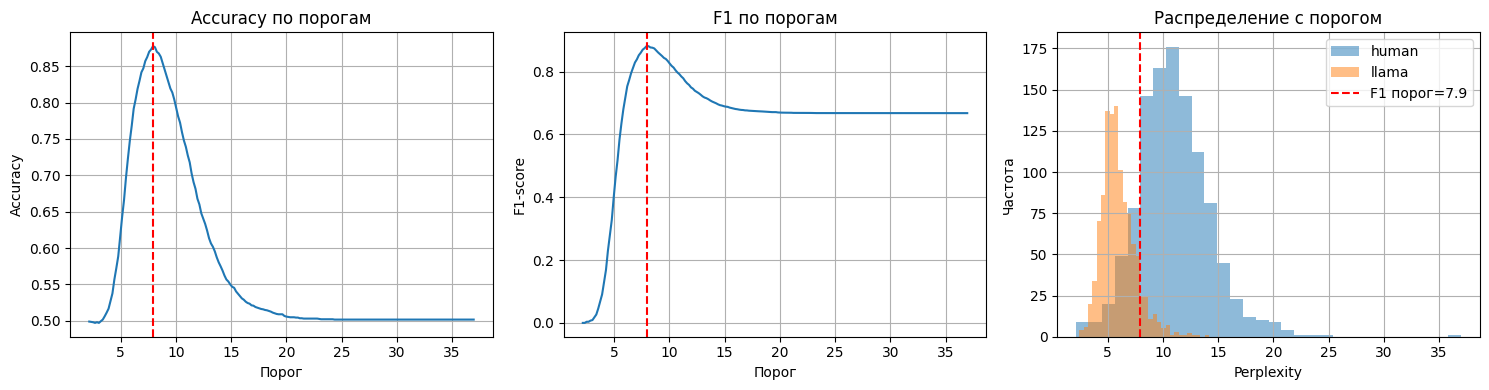

In [33]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

all_ppl = np.array(val_human_ppl + val_llama_ppl)
y_true = [0] * len(val_human_ppl) + [1] * len(val_llama_ppl)

thresholds = np.linspace(min(all_ppl), max(all_ppl), 200)

best_acc = 0
best_thresh_acc = None
acc_scores = []

for thresh in thresholds:
    y_pred = [1 if ppl < thresh else 0 for ppl in all_ppl]
    acc = accuracy_score(y_true, y_pred)
    acc_scores.append(acc)
    if acc > best_acc:
        best_acc = acc
        best_thresh_acc = thresh

best_f1 = 0
best_thresh_f1 = None
f1_scores = []

for thresh in thresholds:
    y_pred = [1 if ppl < thresh else 0 for ppl in all_ppl]
    f1 = f1_score(y_true, y_pred)
    f1_scores.append(f1)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh_f1 = thresh

y_score = -all_ppl
fpr, tpr, roc_thresholds = roc_curve(y_true, y_score)
youden = tpr - fpr
best_idx = np.argmax(youden)
best_thresh_youden = -roc_thresholds[best_idx]
best_youden = youden[best_idx]

print(f"Accuracy порог: {best_thresh_acc:.2f} (acc={best_acc:.4f})")
print(f"F1 порог:       {best_thresh_f1:.2f} (f1={best_f1:.4f})")
print(f"Youden порог:   {best_thresh_youden:.2f} (youden={best_youden:.4f})")

# Визуализация
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(thresholds, acc_scores)
plt.axvline(best_thresh_acc, color='red', linestyle='--')
plt.xlabel('Порог')
plt.ylabel('Accuracy')
plt.title('Accuracy по порогам')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(thresholds, f1_scores)
plt.axvline(best_thresh_f1, color='red', linestyle='--')
plt.xlabel('Порог')
plt.ylabel('F1-score')
plt.title('F1 по порогам')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.hist(val_human_ppl, bins=30, alpha=0.5, label='human')
plt.hist(val_llama_ppl, bins=30, alpha=0.5, label='llama')
plt.axvline(best_thresh_f1, color='red', linestyle='--', label=f'F1 порог={best_thresh_f1:.1f}')
plt.xlabel('Perplexity')
plt.ylabel('Частота')
plt.title('Распределение с порогом')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [34]:
with open('test_human.txt', 'r', encoding='utf-8') as f:
    test_human = [line.strip() for line in f.readlines() if line.strip()]

with open('test_llama.txt', 'r', encoding='utf-8') as f:
    test_llama = [line.strip() for line in f.readlines() if line.strip()]

print(f"Тест: human={len(test_human)}, llama={len(test_llama)}")

test_human_ppl = [get_perplexity(model, text) for text in test_human]
test_human_ppl = [x for x in test_human_ppl if x is not None]

test_llama_ppl = [get_perplexity(model, text) for text in test_llama]
test_llama_ppl = [x for x in test_llama_ppl if x is not None]

print(f"\nТестовая перплексия:")
print(f"  Human среднее: {np.mean(test_human_ppl):.2f}")
print(f"  Llama среднее: {np.mean(test_llama_ppl):.2f}")

Тест: human=1097, llama=1102

Тестовая перплексия:
  Human среднее: 10.91
  Llama среднее: 5.99


In [35]:
test_all_ppl = np.array(test_human_ppl + test_llama_ppl)
y_test_true = [0] * len(test_human_ppl) + [1] * len(test_llama_ppl)

final_threshold = best_thresh_f1
y_test_pred = [1 if ppl < final_threshold else 0 for ppl in test_all_ppl]

print(f"Используем порог по F1: {final_threshold:.2f}")
print(f"Предсказано machine: {sum(y_test_pred)} из {len(y_test_pred)}")

Используем порог по F1: 7.94
Предсказано machine: 1134 из 2199


In [30]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

test_acc = accuracy_score(y_test_true, y_test_pred)
test_f1 = f1_score(y_test_true, y_test_pred)
test_auc = roc_auc_score(y_test_true, -test_all_ppl)

print(f"Accuracy:  {test_acc:.4f}")
print(f"F1-score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_auc:.4f}")

cm = confusion_matrix(y_test_true, y_test_pred)
print("\nМатрица ошибок:")
print("           Pred human  Pred machine")
print(f"Actual human    {cm[0,0]:5d}      {cm[0,1]:5d}")
print(f"Actual machine  {cm[1,0]:5d}      {cm[1,1]:5d}")

Accuracy:  0.8627
F1-score:  0.8649
ROC-AUC:   0.9306

Матрица ошибок:
           Pred human  Pred machine
Actual human      930        167
Actual machine    135        967


In [36]:
print(f"{'Метрика':<12} {'Валидация':>10} {'Тест':>10} {'Разница':>10}")
print("-"*50)
print(f"{'F1-score':<12} {best_f1:>10.4f} {test_f1:>10.4f} {test_f1 - best_f1:>+10.4f}")
print(f"{'Accuracy':<12} {best_acc:>10.4f} {test_acc:>10.4f} {test_acc - best_acc:>+10.4f}")
print(f"{'ROC-AUC':<12} {val_auc:>10.4f} {test_auc:>10.4f} {test_auc - val_auc:>+10.4f}")

Метрика       Валидация       Тест    Разница
--------------------------------------------------
F1-score         0.8811     0.8649    -0.0162
Accuracy         0.8776     0.8627    -0.0149
ROC-AUC          0.9299     0.9306    +0.0007


/tmp/ipykernel_4219/1287113595.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data_to_plot, labels=['human', 'llama'], patch_artist=True)


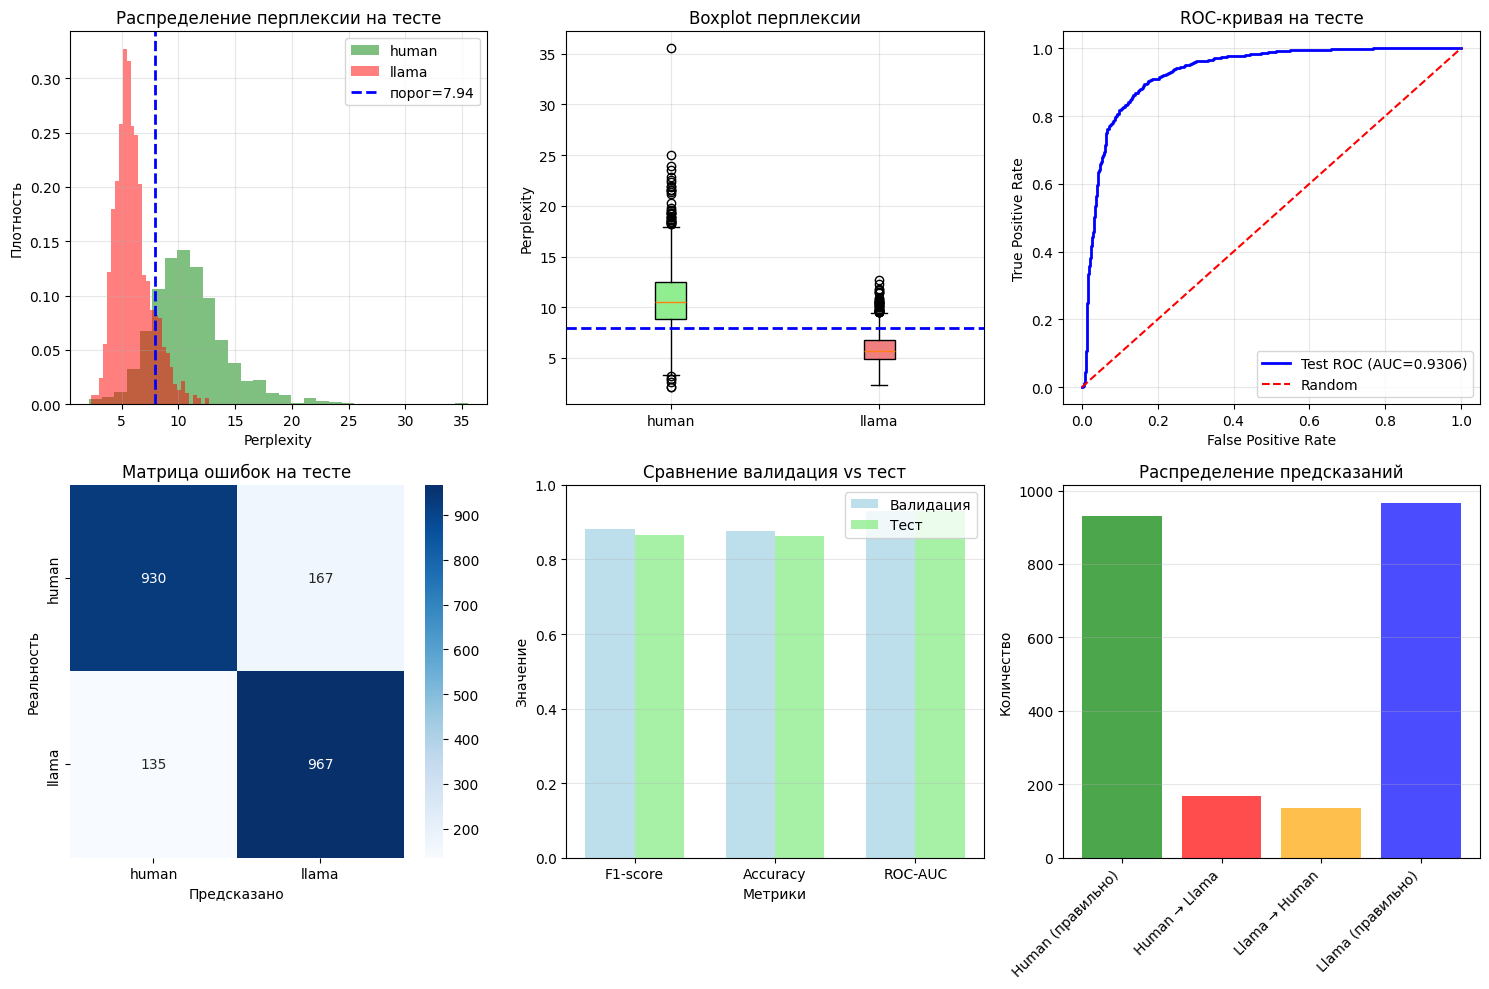


Итоговые метрики на тесте (порог F1=7.94):
  Accuracy: 0.8627
  F1-score: 0.8649
  ROC-AUC:  0.9306


In [39]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, confusion_matrix
import seaborn as sns

test_machine_ppl = test_llama_ppl
y_test_true = [0]*len(test_human_ppl) + [1]*len(test_machine_ppl)
y_test_score = -np.array(test_human_ppl + test_machine_ppl)

plt.figure(figsize=(15, 10))

# 1. Распределение перплексии на тесте
plt.subplot(2, 3, 1)
plt.hist(test_human_ppl, bins=30, alpha=0.5, label='human', density=True, color='green')
plt.hist(test_machine_ppl, bins=30, alpha=0.5, label='llama', density=True, color='red')
plt.axvline(x=final_threshold, color='blue', linestyle='--', linewidth=2, 
            label=f'порог={final_threshold:.2f}')
plt.xlabel('Perplexity')
plt.ylabel('Плотность')
plt.title('Распределение перплексии на тесте')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Boxplot
plt.subplot(2, 3, 2)
data_to_plot = [test_human_ppl, test_machine_ppl]
bp = plt.boxplot(data_to_plot, labels=['human', 'llama'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightgreen')
bp['boxes'][1].set_facecolor('lightcoral')
plt.axhline(y=final_threshold, color='blue', linestyle='--', linewidth=2)
plt.ylabel('Perplexity')
plt.title('Boxplot перплексии')
plt.grid(True, alpha=0.3)

# 3. ROC-кривая
plt.subplot(2, 3, 3)
fpr_test, tpr_test, _ = roc_curve(y_test_true, y_test_score)
plt.plot(fpr_test, tpr_test, 'b-', linewidth=2, label=f'Test ROC (AUC={test_auc:.4f})')
plt.plot([0,1], [0,1], 'r--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая на тесте')
plt.legend()
plt.grid(True, alpha=0.3)

# 4. Матрица ошибок
plt.subplot(2, 3, 4)
cm = confusion_matrix(y_test_true, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['human', 'llama'], 
            yticklabels=['human', 'llama'])
plt.xlabel('Предсказано')
plt.ylabel('Реальность')
plt.title('Матрица ошибок на тесте')

# 5. Сравнение метрик валидация vs тест
plt.subplot(2, 3, 5)
metrics = ['F1-score', 'Accuracy', 'ROC-AUC']
val_values = [best_f1, best_acc, val_auc]
test_values = [test_f1, test_acc, test_auc]
x = np.arange(len(metrics))
width = 0.35
plt.bar(x - width/2, val_values, width, label='Валидация', color='lightblue', alpha=0.8)
plt.bar(x + width/2, test_values, width, label='Тест', color='lightgreen', alpha=0.8)
plt.xlabel('Метрики')
plt.ylabel('Значение')
plt.title('Сравнение валидация vs тест')
plt.xticks(x, metrics)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.ylim([0, 1])

# 6. Предсказания по классам
plt.subplot(2, 3, 6)
labels = ['Human (правильно)', 'Human → Llama', 'Llama → Human', 'Llama (правильно)']
values = [cm[0,0], cm[0,1], cm[1,0], cm[1,1]]
colors = ['green', 'red', 'orange', 'blue']
plt.bar(labels, values, color=colors, alpha=0.7)
plt.ylabel('Количество')
plt.title('Распределение предсказаний')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nИтоговые метрики на тесте (порог F1={final_threshold:.2f}):")
print(f"  Accuracy: {test_acc:.4f}")
print(f"  F1-score: {test_f1:.4f}")
print(f"  ROC-AUC:  {test_auc:.4f}")